# App Store ML — Midterm
Research question: can seven metadata features identify rating ≥4.5 among existing US apps with ≥50 ratings? This notebook reads generated artifacts. Run the pipeline first. Neural networks, NLP and Streamlit are reserved for Final.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
OUT = ROOT / 'outputs'
assert (OUT / 'reports/provenance.json').exists(), 'Run python -m appstore_ml.run first'
provenance = json.loads((OUT / 'reports/provenance.json').read_text())
print('DATA STATUS:', provenance['data_kind'])

DATA STATUS: real_api


## Source, cleaning and sampling

In [2]:
display(Markdown((OUT / 'reports/data_card.md').read_text()))

# Data card
Status: real_api. Source: Apple iTunes Search API, US storefront; software only.
Collection: 2026-10-07T20:53:06.749227+00:00 to 2026-10-07T20:53:58.426835+00:00 (UTC).
Instructor conditions are recorded in config/source_approval.json.
Apple describes API content as promotional. The API documentation is not evidence that
robots.txt permits collection: /search* is disallowed there. Instructor approval is course approval,
not a statement about Apple's permission. Raw responses and descriptions must not be published.

## Sampling and provenance
132 interleaved, prespecified keyword queries; pilot uses fitness, education, puzzle game.
Main responses are limited to 200 each; minimum 3.2 seconds between request starts, retries included.
Stop after reaching at least 2,000 eligible distinct apps; require at least 1,500 to train.
Raw bytes, request parameters, timestamp and SHA-256 are stored under ignored data/raw.
Search results overlap and are ranking-biased. The dataset is not representative of all apps.

## Cleaning audit
{
  "raw_rows": 2763,
  "excluded": {
    "invalid_track_id": 0,
    "invalid_collection_time": 0,
    "not_software": 0,
    "duplicate_track_id": 276,
    "non_usd_or_missing_currency": 0,
    "invalid_or_below_50_ratings": 458,
    "invalid_or_missing_rating": 0
  },
  "clean_rows": 2029,
  "class_counts": {
    "0": 378,
    "1": 1651
  },
  "missing_features": {
    "price_usd": 0,
    "size_mb": 0,
    "language_count": 0,
    "release_year": 0,
    "update_recency_days": 0,
    "primary_genre": 0,
    "content_advisory_rating": 0
  },
  "missing_description": 0,
  "collection_start": "2026-10-07T20:53:06.749227+00:00",
  "collection_end": "2026-10-07T20:53:58.426835+00:00",
  "minimum_met": true
}

## Decisions
1. Require positive integer trackId, a valid collection timestamp and kind=software.
2. Keep the latest complete observation per trackId (stable source-order tie-break); never mix fields across times.
3. Keep USD rows; do not assume a foreign or unknown currency is dollars.
4. Require an integer userRatingCount >=50 and a finite averageUserRating in [0,5].
5. Define high_rated = int(averageUserRating >=4.5); exactly 4.5 belongs to class 1.
6. Negative price, nonpositive size and malformed values become missing features.
7. fileSizeBytes / 1,000,000 gives decimal MB. Languages are distinct normalized valid codes;
   an explicit empty list means zero, an absent list means missing.
8. Release year before 2008 or after collection is missing. Future updates, and updates preceding
   a valid release, are missing. Recency uses full elapsed days at each row's collection timestamp.
9. Preserve missing features for fold-local imputation; do not fill with global medians.
10. Descriptions remain private for Final. Models see only price_usd, size_mb, language_count, release_year, update_recency_days, primary_genre, content_advisory_rating.

## Target leakage
averageUserRating forms the label. userRatingCount only filters eligibility.
Neither is a feature. No current-version rating, ID, app name, description or developer ID enters the model.
contentAdvisoryRating is an allowed age-content category, not a user rating.

## Split and storage
data/splits/split.csv preserves track IDs and train/test assignments privately.
The fingerprint detects data changes. Recollection requires a separate run directory and a new reported experiment.
Public outputs are aggregate metrics/figures and anonymized diagnostic cases.
Local runs retain original JSON and models in ignored directories.
Cloud runs retain raw files only for their runner lifetime; their public artifact excludes raw data,
app-level cleaned data, split IDs, models and private predictions. Run locally to keep a private raw archive.
Do not upload these excluded files to this public repository.

Sources: https://performance-partners.apple.com/search-api; https://itunes.apple.com/robots.txt; https://scikit-learn.org/stable/modules/cross_validation.html.


## Training-only exploratory analysis

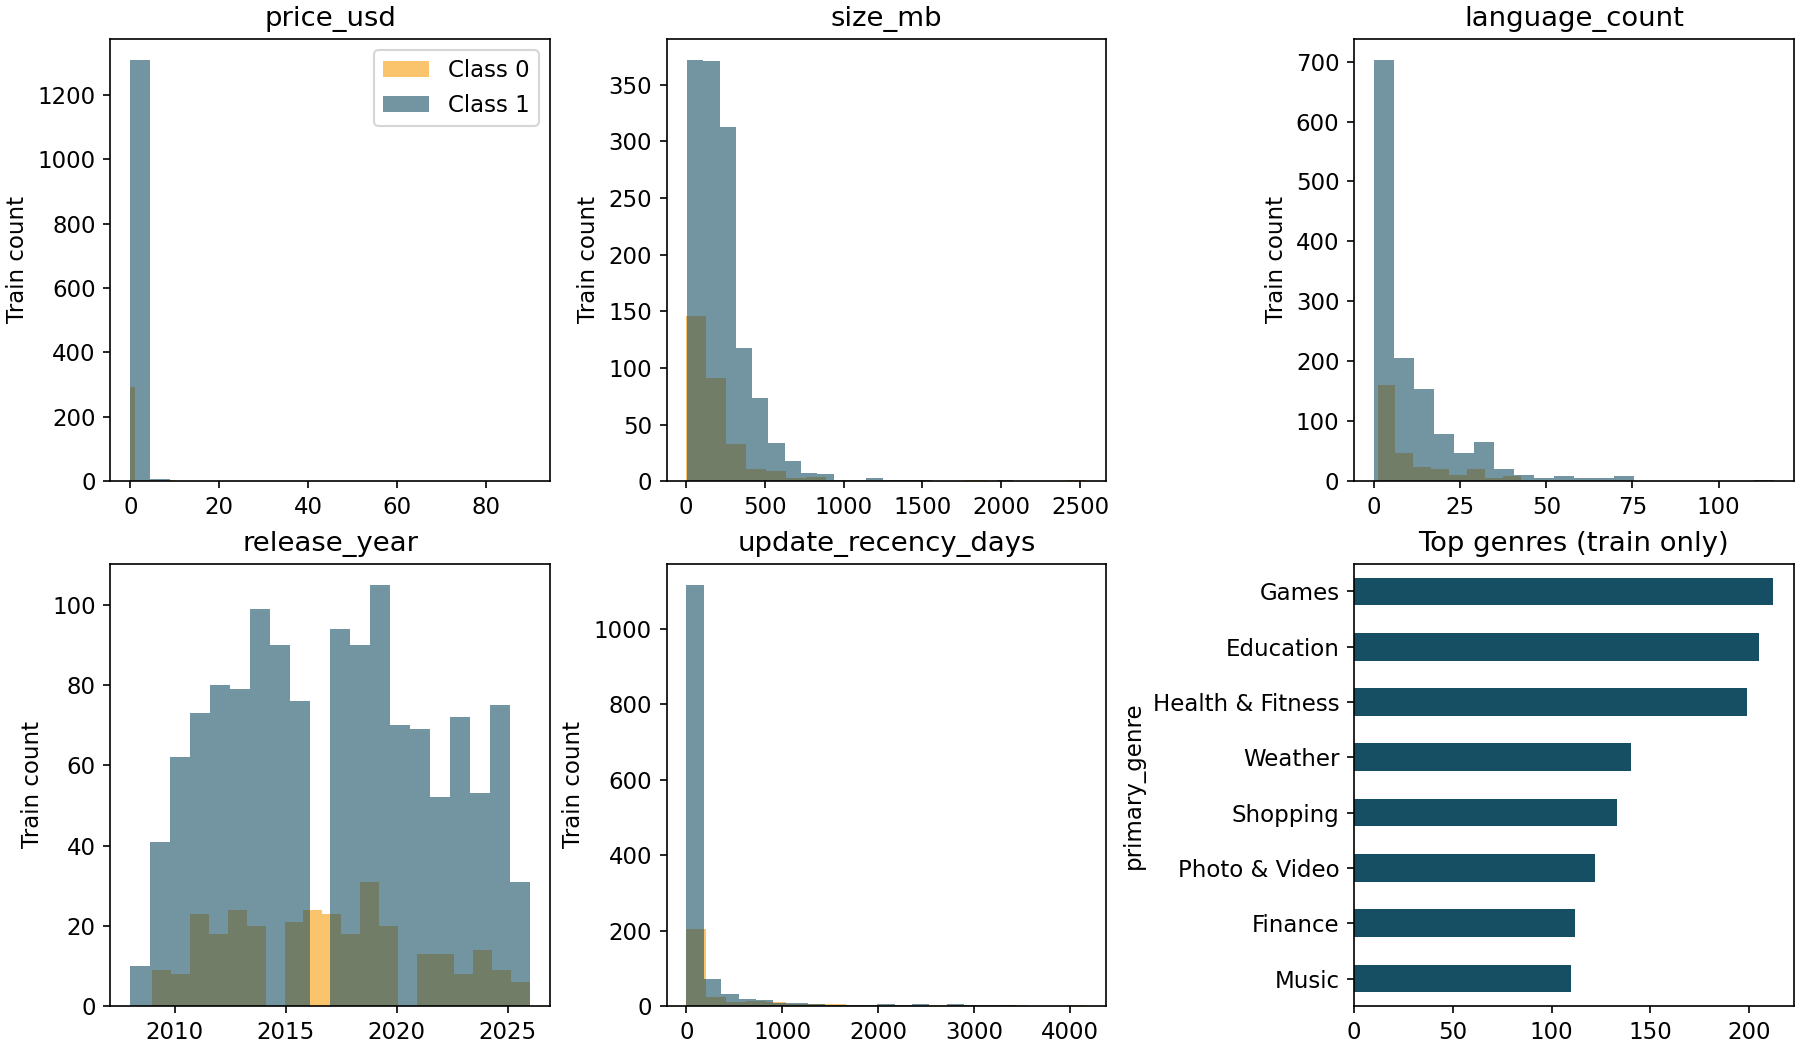

In [3]:
display(Image(filename=str(OUT / 'figures/train_eda.png')))

## Models and validation
Dummy, Decision Tree, KNN and SVM use fixed prespecified settings. A permanent stratified 80/20 split uses seed 42. Five-fold CV is performed only inside train. Numeric median imputation/scaling and categorical imputation/one-hot encoding are Pipeline steps. Models never receive user-rating fields, descriptions, names or IDs.

In [4]:
display(pd.read_csv(OUT / 'reports/cv_metrics.csv'))
display(pd.read_csv(OUT / 'reports/test_metrics.csv'))

,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,train_f1_mean,f1_generalization_gap
0,Dummy,0.897419,0.000909,0.500000,0.000000,0.813926,0.001495,1.000000,0.000000,0.500000,0.000000,0.897418,-6.209847e-08
1,Decision Tree,0.877893,0.006761,0.672301,0.039568,0.839713,0.008870,0.919754,0.007332,0.575751,0.025371,0.909255,3.136262e-02
2,KNN,0.896013,0.008506,0.700701,0.034147,0.833454,0.009848,0.968977,0.018395,0.560608,0.030287,1.000000,1.039873e-01
3,SVM,0.898861,0.002743,0.701320,0.032732,0.821437,0.002006,0.992436,0.007561,0.524305,0.009299,0.905417,6.555237e-03


,model,test_n,f1,roc_auc,precision,recall,balanced_accuracy
0,Dummy,406,0.896739,0.500000,0.812808,1.000000,0.500000
1,Decision Tree,406,0.888252,0.677731,0.842391,0.939394,0.588118
2,KNN,406,0.896359,0.638616,0.833333,0.969697,0.563796
3,SVM,406,0.900826,0.619976,0.825758,0.990909,0.541507


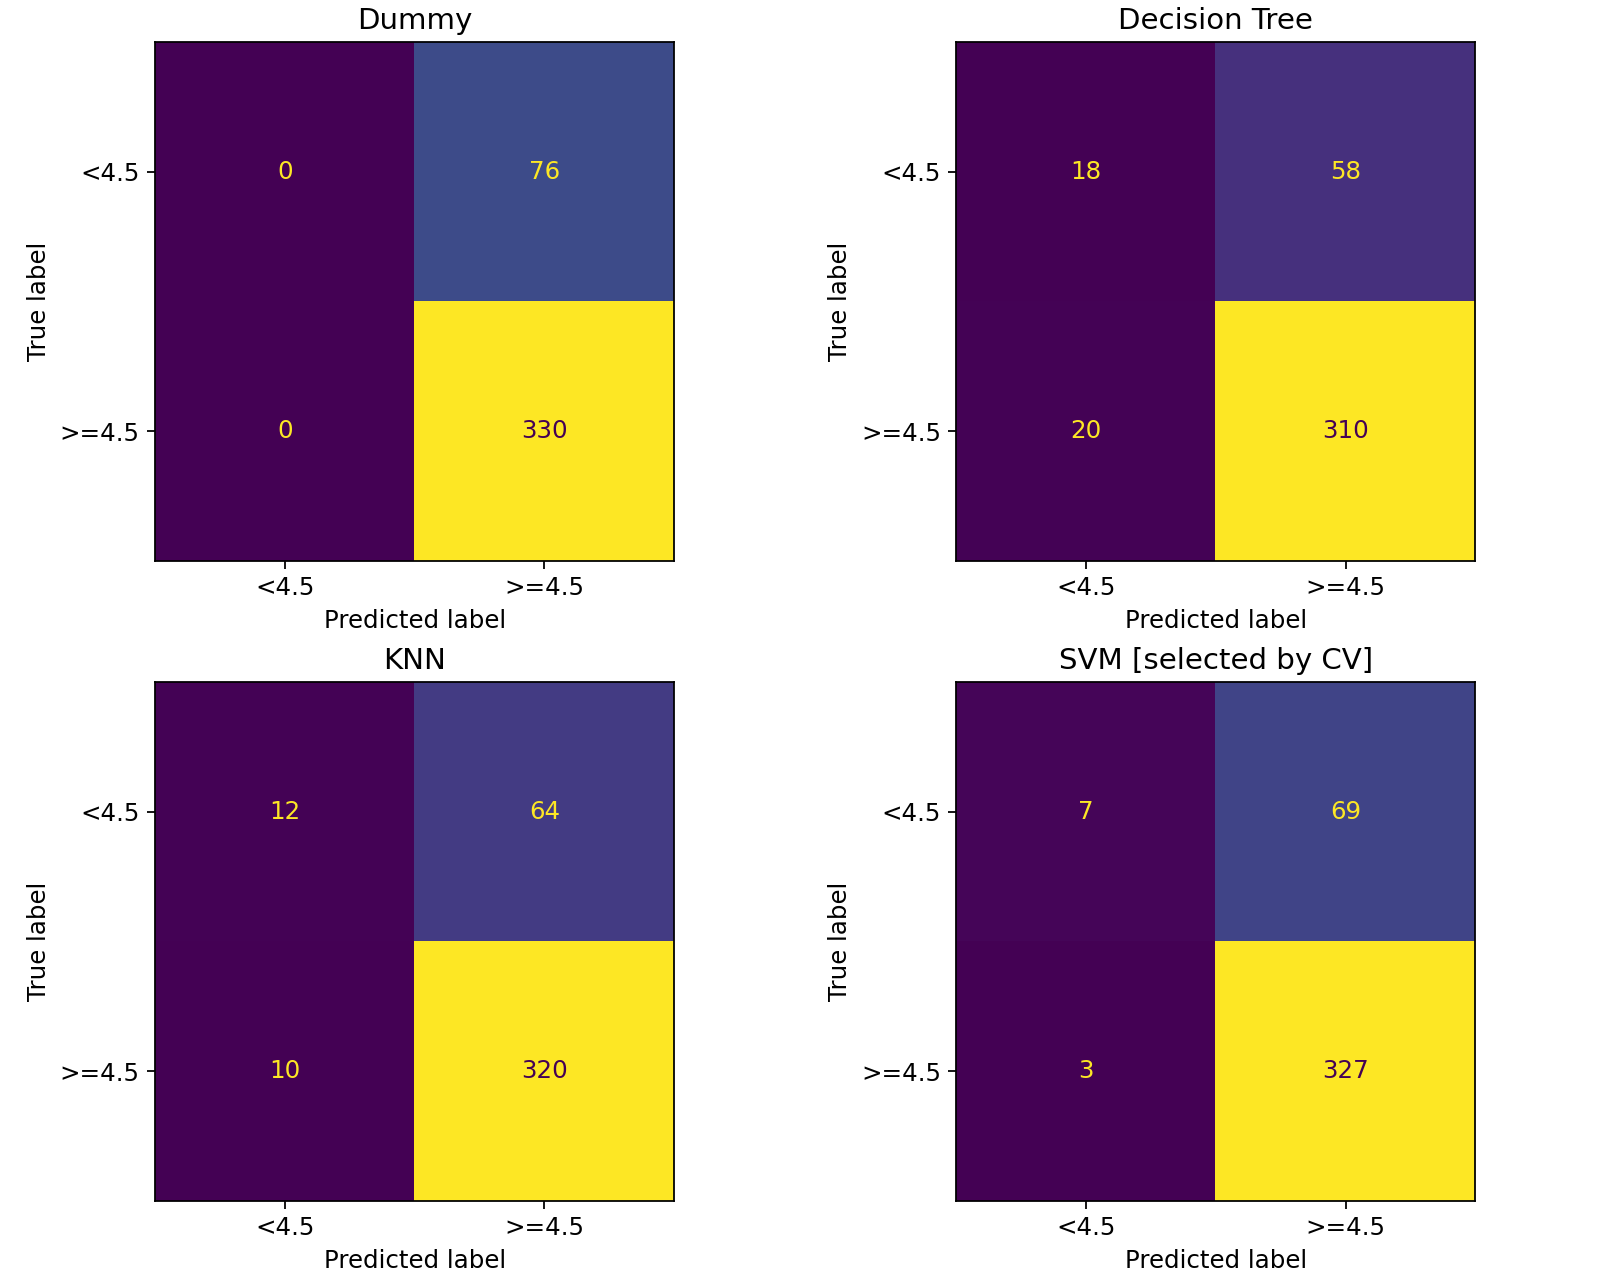

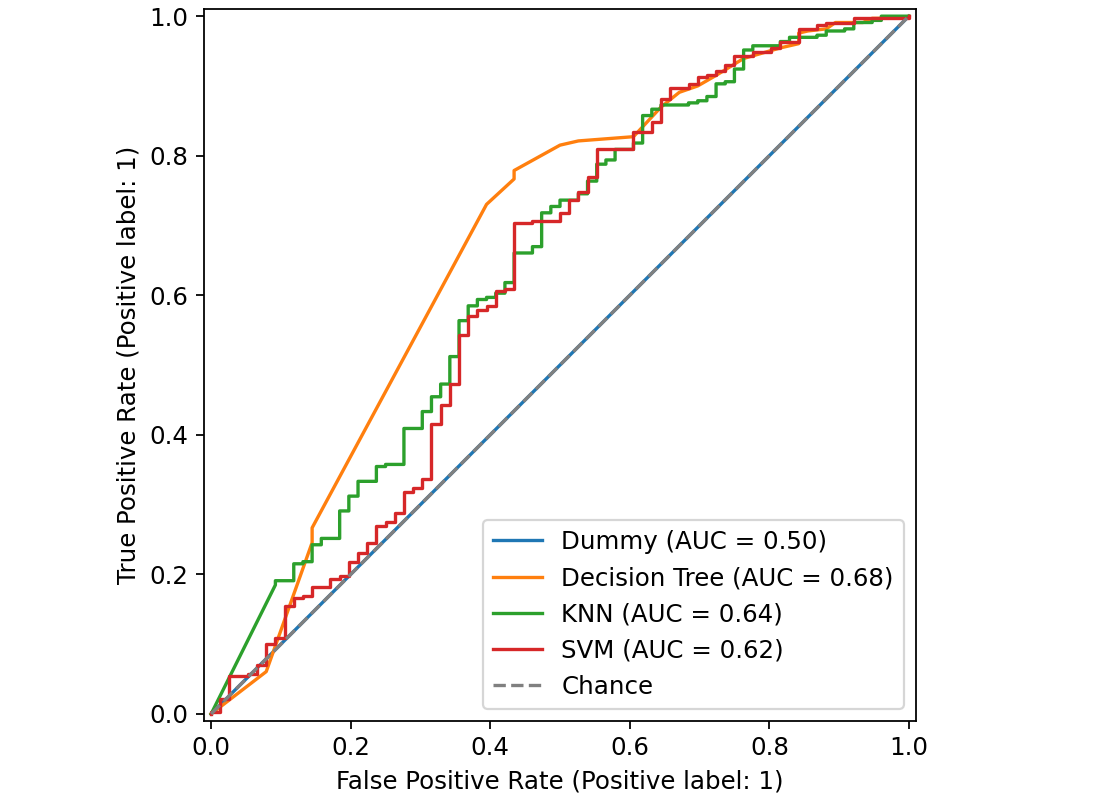

In [5]:
display(Image(filename=str(OUT / 'figures/confusion_matrices.png')))
display(Image(filename=str(OUT / 'figures/roc_curves.png')))

## Error analysis and conclusions

In [6]:
display(pd.read_csv(OUT / 'reports/error_cases_anonymized.csv'))
display(Markdown((OUT / 'reports/results.md').read_text()))

,case,error_type,actual_class,predicted_class,observation,interpretation
0,Case 1,FP,0,1,True rating is within 0.1 of the 4.5 boundary,Descriptive association; no causal explanation...
1,Case 2,FP,0,1,True rating is within 0.1 of the 4.5 boundary,Descriptive association; no causal explanation...
2,Case 3,FP,0,1,True rating is within 0.1 of the 4.5 boundary,Descriptive association; no causal explanation...
3,Case 4,FN,1,0,Metadata alone does not explain the observed r...,Descriptive association; no causal explanation...
4,Case 5,FN,1,0,Metadata alone does not explain the observed r...,Descriptive association; no causal explanation...
5,Case 6,FN,1,0,Metadata alone does not explain the observed r...,Descriptive association; no causal explanation...


# Midterm results
Data status: **real_api**. These metrics are generated by the pipeline, never manually entered.

## Research question
Can seven app metadata attributes distinguish rating >=4.5 from <4.5 among existing US App Store
applications with at least 50 ratings at collection time?

## Data and validation
Eligible apps: 2029. Class counts: {'0': 378, '1': 1651}.
Collection interval (UTC): 2026-10-07T20:53:06.749227+00:00 to 2026-10-07T20:53:58.426835+00:00.
Fixed stratified 80/20 split, random_state=42. Five-fold stratified CV inside training.
Every imputer, scaler and encoder is fitted inside a Pipeline on the applicable training fold.
No hyperparameter or threshold search was performed. Selection used CV F1 only; ties use model name.

## Cross-validation
F1, precision and recall refer to class 1. Standard deviations are sample SD (ddof=1), not confidence intervals.

| model | cv_f1_mean | cv_f1_std | cv_roc_auc_mean | cv_roc_auc_std | cv_precision_mean | cv_recall_mean | f1_generalization_gap |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Dummy | 0.897 | 0.001 | 0.500 | 0.000 | 0.814 | 1.000 | -0.000 |
| Decision Tree | 0.878 | 0.007 | 0.672 | 0.040 | 0.840 | 0.920 | 0.031 |
| KNN | 0.896 | 0.009 | 0.701 | 0.034 | 0.833 | 0.969 | 0.104 |
| SVM | 0.899 | 0.003 | 0.701 | 0.033 | 0.821 | 0.992 | 0.007 |

See cv_metrics.csv for mean and SD of every metric and cv_folds_metrics.csv for individual folds.

## Fixed holdout
| model | test_n | f1 | roc_auc | precision | recall | balanced_accuracy |
| --- | --- | --- | --- | --- | --- | --- |
| Dummy | 406 | 0.897 | 0.500 | 0.813 | 1.000 | 0.500 |
| Decision Tree | 406 | 0.888 | 0.678 | 0.842 | 0.939 | 0.588 |
| KNN | 406 | 0.896 | 0.639 | 0.833 | 0.970 | 0.564 |
| SVM | 406 | 0.901 | 0.620 | 0.826 | 0.991 | 0.542 |
SVM: holdout F1 0.901 vs Dummy 0.897 (gain +0.004); ROC-AUC 0.620. It detected 7/76 lower-rated apps. The F1 gain is descriptive; no statistical significance is claimed.

A majority predictor can have high positive-class F1 under imbalance. Inspect ROC-AUC, balanced
accuracy and both rows of the confusion matrix. SVM ROC-AUC uses decision scores, not probabilities.
Default classification thresholds are unchanged.

## Real error cases (anonymized)
Cases are selected within each error type by closeness to the rating boundary, then trackId.
The identifiers, names, exact ratings and descriptions are withheld from public reports.
The full audit table is in outputs/private/test_predictions.csv on the machine that ran the study.

| case | error_type | actual_class | predicted_class | observation | interpretation |
| --- | --- | --- | --- | --- | --- |
| Case 1 | FP | 0 | 1 | True rating is within 0.1 of the 4.5 boundary | Descriptive association; no causal explanation is established. |
| Case 2 | FP | 0 | 1 | True rating is within 0.1 of the 4.5 boundary | Descriptive association; no causal explanation is established. |
| Case 3 | FP | 0 | 1 | True rating is within 0.1 of the 4.5 boundary | Descriptive association; no causal explanation is established. |
| Case 4 | FN | 1 | 0 | Metadata alone does not explain the observed rating | Descriptive association; no causal explanation is established. |
| Case 5 | FN | 1 | 0 | Metadata alone does not explain the observed rating | Descriptive association; no causal explanation is established. |
| Case 6 | FN | 1 | 0 | Metadata alone does not explain the observed rating | Descriptive association; no causal explanation is established. |

These observations do not establish why users assigned a rating.

## Limits
- A query-ranked convenience sample is not a random sample of the App Store.
- The >=50 criterion selects established apps; these results do not predict pre-launch success.
- Features and labels describe a single collection period; app ratings and metadata can change.
- Update recency is a snapshot feature and may reflect a consequence of popularity.
- Multiple apps from the same developer may occur in both splits; a future group/time split is needed.
- CV was used to choose a model, so its winning CV mean can be optimistic; the holdout is untouched by selection.
- Seven metadata features omit usability, bugs, marketing, review text and other possible causes.

## Next phase
Neural network, description/review text analysis and Streamlit are reserved for Final.
Raw descriptions have been captured privately; no text is used in Midterm features.

## Sources
- [Apple Search API](https://performance-partners.apple.com/search-api)
- [iTunes robots.txt](https://itunes.apple.com/robots.txt): contains Disallow: /search*, checked 2026-10-08.
- [scikit-learn cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)

## Execution provenance
Source commit: ae4e81218cf5039db10ee6e9c380423f7008807e; Python: 3.11.17;
scikit-learn: 1.6.1. Dataset fingerprint: 5c4169bb4bf7cf5f8ae8c14110dc8aef6948a645657b869ff77c21c4631bc8fd.


## Reproducibility
Code, configuration, split fingerprint and package versions are recorded. Private raw JSON/metadata, cleaned data, split IDs and model files stay outside version control. The seven-feature experiment does not establish pre-launch success prediction.